In [14]:
# ===============================
# Professional ML Preprocessing Pipeline
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import r2_score

# --------- Load your dataset ----------
df = pd.read_csv("car_price_prediction_dataset.csv")  # Replace with your file

# --------- Separate target variable ----------
target_column = "Price(USD)"  # Replace with your target
X = df.drop(target_column, axis=1)
y = df[target_column]

# --------- Identify column types ----------
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# --------- Preprocessing for numeric data ----------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())                   # Feature scaling
])

# --------- Preprocessing for categorical data ----------
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encoding
])

# --------- Combine preprocessing ----------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# --------- Full pipeline ----------
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selector', VarianceThreshold(threshold=0.01))  # Remove low-variance features
])

# --------- Train-test split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------- Fit pipeline on training data ----------
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# --------- Now ready for ML models ----------
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (800, 26)
Processed test shape: (200, 26)


C:\Users\MIR SHAHADUT HOSSAIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_processed, y_train)
print("Training complete!")

Training complete!


In [11]:
y_pred = model.predict(X_test_processed)

print("Model Predicted")
print(y_pred)

Model Predicted
[37450.93477792 22216.11213694 26412.21384128 41434.35108223
 37235.1637899  21330.79352243 33409.51436669 36521.46893363
 11889.43210938 39019.36005634 10188.80707164 18822.28272517
 47404.33893307 42097.91605994 13316.65986891 41690.45142429
 17264.48440703 13094.95398577  8395.5452846  19159.28868593
 29027.13833904 11023.19556961 22371.70745056 32179.00045397
 18800.56429054 37021.80598354  7944.49371173 13493.72196922
 30222.36519561 31039.52497718 18573.58843761 23165.506781
 16146.30542097 30254.57869542 29425.77097707 38804.00054633
 15320.14627469 19567.54861046 41794.83809527 11502.80835824
 33715.78661177 22666.71346643 15408.8307127   3873.55414369
 27327.12085459 47800.27908632 31293.63123101 21471.40056579
 34914.63320727 39411.76925483 44031.48334278  8844.52395264
 33155.89610637 35236.02690285 18509.14947232 25993.56323497
 16436.33777506 19619.85698286  8677.31487851 12091.84914646
 25388.75736415 11513.09188739 24319.78667497 27890.1507633
 42725.0226

In [7]:
print("Intercept: ", model.intercept_)
print("Slope: ", model.coef_)

Intercept:  37554.370141819425
Slope:  [  5215.6380246   -3353.65318537   2307.06539702    245.6334598
   -886.71190195   3755.8604946  -15755.5747856  -14530.9810178
 -12558.44325198 -15554.70397917   4296.08464586 -13855.0732169
 -11533.19279469  -9087.25033454    569.83264812   -153.96067856
    118.68333464    244.17904548    350.61311721    282.71660787
    319.43389799    755.59022937    645.39259386  -9592.6890433
  -3923.22820347 -13705.8953287 ]


In [12]:
r2 = r2_score(y_test, y_pred)
print(f"R² score: {r2:.4f}")

R² score: 0.9224


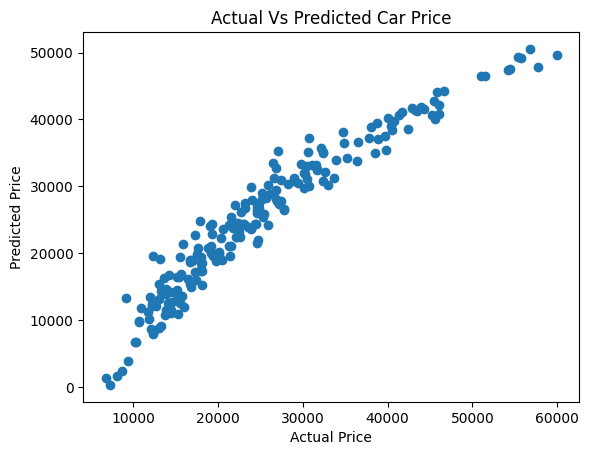

In [15]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Vs Predicted Car Price")

plt.show()